## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

In [3]:
from gridsample.utils import save_shapefiles
from gridsample.mapping.plot import create_interactive_map

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels"

## Load cleaned khasras

In [5]:
# # Dhar
# dhar_processed_areas_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "dhar_cleaned_khasras.parquet")
# dhar_processed_areas_gdf["source"] = "dhar"

In [6]:
# Sagar
sagar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "sagar_cleaned_khasras.parquet")
# filter to only the "PA" PAR_TYPE (since it looks like the barren land)
sagar_gdf = sagar_gdf[sagar_gdf["PAR_TYPE"] == "PA"]

In [7]:
sagar_gdf

,,source,geometry,FID,UNQID,DISTRICT_I,TEHSIL_ID,R_I_ID,HALKA_ID,VILLAGE_ID,KHASRA_ID,...,KHASRA_UNQ,REMAINING_,BLOCK_NO,BLOCK_ID,SHAPE_Leng,SHAPE_Area,Mokalpur_g,OBJECTID_1,village_name,khasra_id
1,0,sagar,"POLYGON ((78.76401 23.58272, 78.76398 23.58267...",1,17680194,10,12,03,00061,274,0,...,0,0,,0,3770.241032,291891.128041,x,None,khamkuwa,SAGAR_17680194
6,0,sagar,"POLYGON ((78.75848 23.58061, 78.75858 23.58071...",6,17680261,10,12,03,00061,274,1.100105e+020,...,0,0,,0,673.551379,19033.587642,x,None,khamkuwa,SAGAR_17680261
9,0,sagar,"POLYGON ((78.76140 23.58232, 78.76129 23.58238...",9,17680195,10,12,03,00061,274,1.100105e+020,...,0,0,,0,819.142439,19671.732025,x,None,khamkuwa,SAGAR_17680195
10,0,sagar,"POLYGON ((78.75639 23.57922, 78.75639 23.57969...",10,17679771,10,12,03,00061,274,1.100105e+020,...,0,0,,0,373.80919,4559.467383,x,None,khamkuwa,SAGAR_17679771
14,0,sagar,"POLYGON ((78.78790 23.56381, 78.78783 23.56372...",14,17680109,10,12,03,00061,274,1.100105e+020,...,0,0,,0,234.282118,2371.774955,x,None,khamkuwa,SAGAR_17680109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,0,sagar,"POLYGON ((78.74928 23.60215, 78.74928 23.60213...",None,17679500,10,12,03,00060,254,1.100105e+020,...,0,0,,0,1584.523133,None,<Null>,46,tekapar,SAGAR_17679500
389,0,sagar,"POLYGON ((78.75258 23.60314, 78.75245 23.60320...",None,17679498,10,12,03,00060,254,1.100105e+020,...,0,0,,0,2648.65747,None,<Null>,48,tekapar,SAGAR_17679498
390,0,sagar,"POLYGON ((78.76967 23.61822, 78.76962 23.61823...",None,17679527,10,12,03,00060,254,1.100105e+020,...,0,0,,0,4996.919226,None,<Null>,49,tekapar,SAGAR_17679527
394,0,sagar,"POLYGON ((78.76081 23.62288, 78.76084 23.62297...",None,17679301,10,12,03,00060,254,1.100105e+020,...,0,0,,0,258.255966,None,<Null>,53,tekapar,SAGAR_17679301


## Combine khasras into continuous parcels

In [8]:
def calculate_pairwise_distances(gdf):
    distances = gdf.geometry.apply(lambda geom1: gdf.geometry.distance(geom1))
    return distances.to_numpy()

In [9]:
def cluster_adjacent_shapes(gdf, distance_threshold):

    gdf_index = gdf.index

    # Step 2: Create a spatial graph
    G = nx.Graph()
    for i, geom1 in enumerate(gdf.geometry):
        for j, geom2 in enumerate(gdf.geometry):
            if i != j and geom1.distance(geom2) < distance_threshold:
                G.add_edge(i, j)

    # Step 3: Find connected components
    connected_components = list(nx.connected_components(G))

    # Step 4: Convert the connected components to a list of labels that matches the input data
    data = []
    for cluster_id, value_set in enumerate(connected_components):
        for value in value_set:
            data.append((value, cluster_id))

    df = pd.DataFrame(data, columns=['index', 'cluster'])
    df.set_index('index', inplace=True)

    # make index of df the same as gdf and assign any missing values as -1
    cluster_labels = df.reindex(gdf_index)["cluster"].fillna(-1).astype(int)

    return cluster_labels

In [10]:
gdf = sagar_gdf.to_crs("24378").reset_index(drop=True)[
    [
        "geometry",
        "UNQID",
        "village_name",
    ]
]

<Axes: >

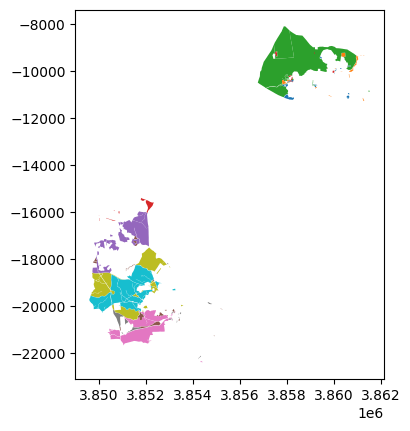

In [11]:
gdf.plot(column="UNQID")

In [12]:
dist_matrix = calculate_pairwise_distances(gdf)

In [13]:
gdf["parcel_id"] = cluster_adjacent_shapes(gdf, distance_threshold=100)

<Axes: >

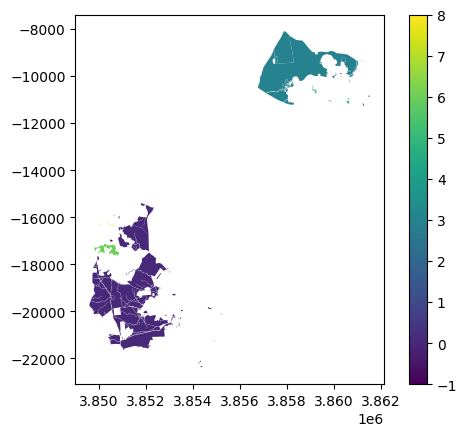

In [14]:
gdf.plot(column='parcel_id', legend=True)

In [15]:
# group by the cluster value and dissolve to make a new GeoDataFrame
clustered_gdf = gdf.dissolve(by='parcel_id').reset_index(drop=False)

In [16]:
# only keep relevant columns
clustered_gdf = clustered_gdf[["parcel_id", "village_name", "geometry"]]

In [17]:
# drop the none-cluster
clustered_gdf = clustered_gdf[clustered_gdf["parcel_id"] != -1]

In [18]:
clustered_gdf["Area (ha)"] = clustered_gdf["geometry"].area / 10**4

In [19]:
larger_than_100ha = clustered_gdf[clustered_gdf["Area (ha)"] > 100]

<Axes: >

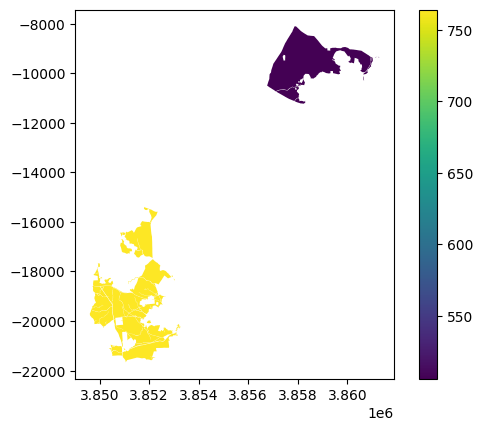

In [20]:
larger_than_100ha.plot(column="Area (ha)", legend=True)

## Save files

In [21]:
save_shapefiles(
    larger_than_100ha.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Sagar",
    "sagar_parcels_initial",
    formats=["parquet", "kml", "csv"],
)

## Scraps

In [22]:
# sagar_gdf[sagar_gdf["UNQID"] == "17677985"].geometry.values[0].distance(
#     sagar_gdf[sagar_gdf["UNQID"] == "17677984"].geometry.values[0]
# )

In [23]:
# sagar_gdf_4326 = sagar_gdf.to_crs("4326")
# sagar_gdf_4326["Lat"] = sagar_gdf_4326.centroid.y
# sagar_gdf_4326["Lon"] = sagar_gdf_4326.centroid.x
# create_interactive_map(sagar_gdf_4326, point_id_col="UNQID", zoom_start=12)

In [24]:
# from sklearn.cluster import HDBSCAN
# clusters = HDBSCAN(min_cluster_size=2, metric="precomputed", n_jobs=-1).fit(dist_matrix)
# gdf['clustering_dbscan'] = clusters.labels_
# gdf.plot(column='clustering_dbscan', legend=True)